# ICA07 — Assessing boundary-layer evolution 

This notebook is a streamlined introduction to reading hourly output from simulations focused on understanding the diurnal cycle of the planetary boundary layer. Case based on AWAKEN simulations

Julie.Lundquist@JHU.edu
2026 February (updated from 2023 version)

# Learning goals
By the end, you should be able to:
1. Read in hourly data from a WRF simulation
2. Assess the vertical resolution of these data in terms of height
3. For a particular point in the domain, create contour plots for comparisons to the canonical boundary-layer cycle over land, including: 
3a. time-height cross section of potential temperature with PBL height plotted on top
3b. time-height cross section of wind speed and wind direction
3c. time-height cross section of TKE_PBL
3d. time series of surface forcing (u_star)
4. Compare these fields for multiple simulations.

In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import xarray as xr
import re

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

from pathlib import Path
import glob

from matplotlib.axes import Axes # Makes the color bar easier to work with
from mpl_toolkits.axes_grid1 import make_axes_locatable # Color bar location
import matplotlib.ticker as mticker


from matplotlib.colors import ListedColormap, BoundaryNorm # Because I'm particular about color tables
from matplotlib.colors import Normalize # Because I'm particular about color tables
from matplotlib.colors import TwoSlopeNorm # to help normalize map factors so color table is centered on zero
 

print("Imports OK")

Imports OK


In [2]:
# -------------------------
# STUDENT: edit these
# -------------------------


# You can support multiple simulations by putting them in a dict
CASES = {
    "MYNN_wrfv4.4": Path("/scratch/alpine/jlundqui/AWAKEN/ICA07/MYNN_wrfv4.4/"),
    "MYNN_wrfv4.7.0": Path("/scratch/alpine/jlundqui/AWAKEN/ICA07/MYNN_wrfv4.7.0/"),
#     "YSU": Path("/scratch/alpine/jlundqui/AWAKEN/ICA07/YSU/"),
}

# Choose the domain you want (d01 or d02)
DOMAIN = "d01"   # "d01" or "d02"

# point for timeseries / profiles
lat0 = 36.361661
lon0 = -97.510011

def open_wrf_case(case_dir: Path, domain=DOMAIN):
    files = sorted(case_dir.glob(f"wrfout_{domain}_*"))
    if len(files) == 0:
        raise FileNotFoundError(f"No files matching wrfout_{domain}_* in {case_dir}")
    # concat along Time; combine='nested' is simplest for lists of files
    ds = xr.open_mfdataset(
        files,
        combine="nested",
        concat_dim="Time",
        decode_times=False,   # WRF "Times" is a char array; we'll parse it ourselves
        parallel=False,
        engine="netcdf4",
    )
    return ds, files

datasets = {}
filelists = {}
for name, cdir in CASES.items():
    ds, fl = open_wrf_case(cdir, DOMAIN)
    datasets[name] = ds
    filelists[name] = fl

print("Opened cases:", list(datasets.keys()))
print("Example dataset:", datasets[list(datasets.keys())[0]])


Opened cases: ['MYNN_wrfv4.4', 'MYNN_wrfv4.7.0']
Example dataset: <xarray.Dataset>
Dimensions:                (Time: 48, south_north: 199, west_east: 199,
                            bottom_top: 72, bottom_top_stag: 73,
                            soil_layers_stag: 4, west_east_stag: 200,
                            south_north_stag: 200, seed_dim_stag: 2)
Coordinates:
    XLAT                   (Time, south_north, west_east) float32 dask.array<chunksize=(1, 199, 199), meta=np.ndarray>
    XLONG                  (Time, south_north, west_east) float32 dask.array<chunksize=(1, 199, 199), meta=np.ndarray>
    XTIME                  (Time) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    XLAT_U                 (Time, south_north, west_east_stag) float32 dask.array<chunksize=(1, 199, 200), meta=np.ndarray>
    XLONG_U                (Time, south_north, west_east_stag) float32 dask.array<chunksize=(1, 199, 200), meta=np.ndarray>
    XLAT_V                 (Time, south_north_stag, west

In [3]:
ds

<xarray.Dataset>
Dimensions:                (Time: 48, south_north: 199, west_east: 199,
                            bottom_top: 72, bottom_top_stag: 73,
                            soil_layers_stag: 4, west_east_stag: 200,
                            south_north_stag: 200, seed_dim_stag: 2)
Coordinates:
    XLAT                   (Time, south_north, west_east) float32 dask.array<chunksize=(1, 199, 199), meta=np.ndarray>
    XLONG                  (Time, south_north, west_east) float32 dask.array<chunksize=(1, 199, 199), meta=np.ndarray>
    XTIME                  (Time) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    XLAT_U                 (Time, south_north, west_east_stag) float32 dask.array<chunksize=(1, 199, 200), meta=np.ndarray>
    XLONG_U                (Time, south_north, west_east_stag) float32 dask.array<chunksize=(1, 199, 200), meta=np.ndarray>
    XLAT_V                 (Time, south_north_stag, west_east) float32 dask.array<chunksize=(1, 200, 199), meta=np.ndarray>
    XLONG_V                (Time, south_north_stag, west_east) float32 dask.array<chunksize=(1, 200, 199), meta=np.ndarray>
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, soil_layers_stag,
                                west_east_stag, south_north_stag, seed_dim_stag
Data variables: (12/199)
    Times                  (Time) |S19 dask.array<chunksize=(1,), meta=np.ndarray>
    LU_INDEX               (Time, south_north, west_east) float32 dask.array<chunksize=(1, 199, 199), meta=np.ndarray>
    ZNU                    (Time, bottom_top) float32 dask.array<chunksize=(1, 72), meta=np.ndarray>
    ZNW                    (Time, bottom_top_stag) float32 dask.array<chunksize=(1, 73), meta=np.ndarray>
    ZS                     (Time, soil_layers_stag) float32 dask.array<chunksize=(1, 4), meta=np.ndarray>
    DZS                    (Time, soil_layers_stag) float32 dask.array<chunksize=(1, 4), meta=np.ndarray>
    ...                     ...
    PCB                    (Time, south_north, west_east) float32 dask.array<chunksize=(1, 199, 199), meta=np.ndarray>
    PC                     (Time, south_north, west_east) float32 dask.array<chunksize=(1, 199, 199), meta=np.ndarray>
    LANDMASK               (Time, south_north, west_east) float32 dask.array<chunksize=(1, 199, 199), meta=np.ndarray>
    LAKEMASK               (Time, south_north, west_east) float32 dask.array<chunksize=(1, 199, 199), meta=np.ndarray>
    SST                    (Time, south_north, west_east) float32 dask.array<chunksize=(1, 199, 199), meta=np.ndarray>
    SST_INPUT              (Time, south_north, west_east) float32 dask.array<chunksize=(1, 199, 199), meta=np.ndarray>
Attributes: (12/136)
    TITLE:                            OUTPUT FROM WRF V4.7.1 MODEL
    START_DATE:                      2023-08-23_00:00:00
    SIMULATION_START_DATE:           2023-08-23_00:00:00
    WEST-EAST_GRID_DIMENSION:        200
    SOUTH-NORTH_GRID_DIMENSION:      200
    BOTTOM-TOP_GRID_DIMENSION:       73
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2

## Parse WRF Times into a real datetime coordinate

In [4]:
def wrf_times_to_datetime(ds):
    """
    Convert WRF 'Times' (char array) into pandas datetime and attach as ds['time'] coordinate.
    Works for Times shaped (Time, DateStrLen) or (Time,) strings.
    """
    if "Times" not in ds:
        raise KeyError("Dataset has no 'Times' variable.")

    tvals = ds["Times"].values
    # Cases:
    #  - char array: shape (Time, DateStrLen) dtype 'S1' or 'U1'
    #  - byte strings: shape (Time,) dtype 'S19'
    if tvals.ndim == 2:
        # join each row into a string
        strings = ["".join(row.astype(str)) for row in tvals]
    else:
        strings = [s.decode() if hasattr(s, "decode") else str(s) for s in tvals]

    # WRF format usually "YYYY-MM-DD_HH:MM:SS"
    dt = pd.to_datetime([s.replace("_", " ") for s in strings], errors="coerce")
    return ds.assign_coords(time=("Time", dt))

for name in datasets:
    datasets[name] = wrf_times_to_datetime(datasets[name])

# sanity check
for name, ds in datasets.items():
    print(name, ds["time"].values[0], "→", ds["time"].values[-1], "nt=", ds.dims["Time"])


MYNN_wrfv4.4 2023-08-23T00:00:00.000000000 → 2023-08-24T23:00:00.000000000 nt= 48
MYNN_wrfv4.7.0 2023-08-23T00:00:00.000000000 → 2023-08-24T23:00:00.000000000 nt= 48


## Find the nearest cell to location of interest

In [5]:
def nearest_ij(lat2d, lon2d, lat0, lon0):
    """
    lat2d, lon2d must be 2D arrays (south_north, west_east)
    """
    lat = np.asarray(lat2d)
    lon = np.asarray(lon2d)

    # handle 0..360 lon if present
    lon0_use = lon0 % 360 if (np.nanmax(lon) > 180 and lon0 < 0) else lon0

    dist2 = (lat - lat0)**2 + (lon - lon0_use)**2
    j, i = np.unravel_index(np.nanargmin(dist2), dist2.shape)
    return int(j), int(i)

# Use the first case as the "grid definition"
ref_name = list(datasets.keys())[0]
ref = datasets[ref_name]

# IMPORTANT: take Time=0 to make XLAT/XLONG 2D
lat2d = ref["XLAT"].isel(Time=0).values
lon2d = ref["XLONG"].isel(Time=0).values

j0, i0 = nearest_ij(lat2d, lon2d, lat0, lon0)

print(f"Nearest grid point (j,i)=({j0},{i0})")
print("Grid lat/lon:", float(lat2d[j0, i0]), float(lon2d[j0, i0]))


Nearest grid point (j,i)=(106,89)
Grid lat/lon: 36.36284255981445 -97.51486206054688


## Quick map check of nearest cell

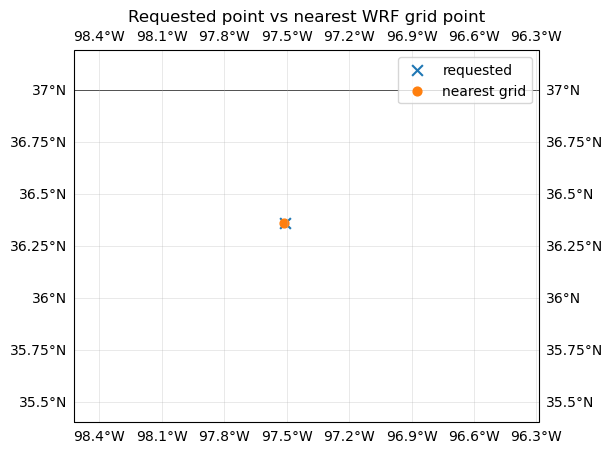

In [6]:
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(6,5))
ax = plt.axes(projection=proj)

bounds = [float(lon2d.min()), float(lon2d.max()), float(lat2d.min()), float(lat2d.max())]
ax.set_extent(bounds, crs=proj)

ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.STATES, linewidth=0.4)
ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)

ax.scatter(lon0, lat0, s=60, marker="x", transform=proj, label="requested")
ax.scatter(lon2d[j0,i0], lat2d[j0,i0], s=40, marker="o", transform=proj, label="nearest grid")

ax.legend()
ax.set_title("Requested point vs nearest WRF grid point")
plt.show()


# Assess vertical resolution in height

## Compute approximate height AGL for mass levels at the point

z_agl shape: (48, 72)
Min dz [m]: 6.2073974609375 Median dz [m]: 1570.455322265625 Max dz [m]: 15636.9599609375


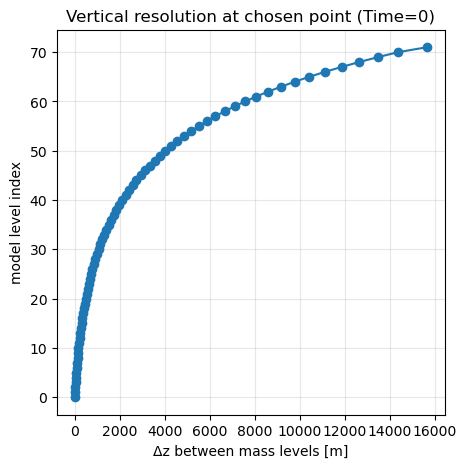

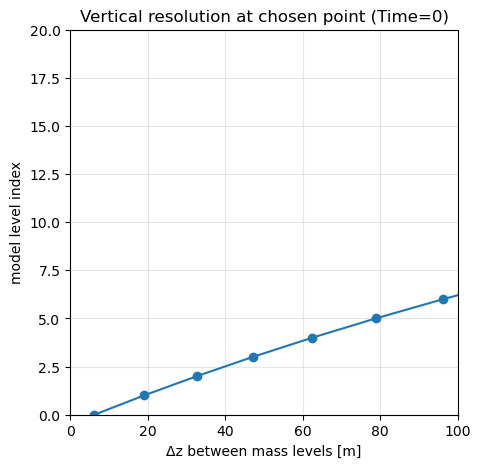

In [7]:
def geopotential_height_agl(ds, j, i):
    """
    Return z_mass_agl [m] with dims (Time, bottom_top) at a single point (j,i).
    """
    g = 9.81
    ph = ds["PH"].isel(south_north=j, west_east=i)     # (Time, bottom_top_stag)
    phb = ds["PHB"].isel(south_north=j, west_east=i)
    z_stag = (ph + phb) / g                           # geometric height at staggered levels
    # destagger to mass levels
    z_mass = 0.5 * (z_stag.isel(bottom_top_stag=slice(0,-1)) + z_stag.isel(bottom_top_stag=slice(1,None)))
    # AGL: subtract terrain height
    hgt = ds["HGT"].isel(Time=0, south_north=j, west_east=i)
    z_agl = z_mass - hgt
    return z_agl

# Example for one case:
z_agl = geopotential_height_agl(ref, j0, i0)
print("z_agl shape:", z_agl.shape)


# Vertical spacing at first time (1D over bottom_top)
dz_da = z_agl.isel(Time=0).diff("bottom_top")   # xarray DataArray
dz = dz_da.values                               # numpy array

print("Min dz [m]:", float(np.nanmin(dz)),
      "Median dz [m]:", float(np.nanmedian(dz)),
      "Max dz [m]:", float(np.nanmax(dz)))

# Plot vertical resolution
fig, ax = plt.subplots(figsize=(5,5))
ax.plot(dz, np.arange(dz.size), marker="o")
ax.set_xlabel("Δz between mass levels [m]")
ax.set_ylabel("model level index")
ax.set_title("Vertical resolution at chosen point (Time=0)")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(5,5))
ax.plot(dz, np.arange(dz.size), marker="o")
ax.set_xlabel("Δz between mass levels [m]")
ax.set_ylabel("model level index")
ax.set_title("Vertical resolution at chosen point (Time=0)")
ax.grid(True, alpha=0.3)
ax.set_ylim(0,20)
ax.set_xlim(0,100)
plt.show()



# Learning goal #3 — Canonical PBL cycle diagnostics at a point
We’ll build reusable “extract at point” utilities, then make time–height plots.
## Helpful derived variables: θ, wind speed, wind direction, u*, PBLH, TSLB, SMOIS, QKE, 

In [8]:
def extract_point_profiles(ds, j, i):
    """
    Returns a dict of DataArrays at a single point (Time, bottom_top) and surface time series.
    """
    # Temperature: T is perturbation potential temperature (K) about 300 K
    theta = ds["T"].isel(south_north=j, west_east=i) + 300.0  # (Time, bottom_top)

    # Staggered winds -> mass points
    U = ds["U"].isel(south_north=j, west_east_stag=slice(i, i+2))  # need i and i+1
    U = 0.5 * (U.isel(west_east_stag=0) + U.isel(west_east_stag=1))

    V = ds["V"].isel(south_north_stag=slice(j, j+2), west_east=i)
    V = 0.5 * (V.isel(south_north_stag=0) + V.isel(south_north_stag=1))

    wspd = np.hypot(U, V)
    wdir = (270.0 - np.degrees(np.arctan2(V, U))) % 360.0

    # PBL height and friction velocity (surface)
    pblh = ds["PBLH"].isel(south_north=j, west_east=i)  # (Time,)
    ust = ds["UST"].isel(south_north=j, west_east=i)    # (Time,)

    # TKE: depends on physics/output; common names: "TKE_PBL", "TKE", "QKE"
    tke_name = None
    for cand in ["QKE", "TKE_PBL", "TKE"]:
        if cand in ds.variables:
            tke_name = cand
            print(cand)
            break
    tke = ds[tke_name].isel(south_north=j, west_east=i) if tke_name else None
    
    # other surface variables
    tslb = ds["TSLB"].isel(south_north=j, west_east=i)  # (Time,)
    tsk = ds["TSK"].isel(south_north=j, west_east=i)  # (Time,)
    smois = ds["SMOIS"].isel(south_north=j, west_east=i)  # (Time,)
    t2 = ds["T2"].isel(south_north=j, west_east=i)  # (Time,)


    return dict(theta=theta, wspd=wspd, wdir=wdir, pblh=pblh, ust=ust, tke=tke, tke_name=tke_name, tslb=tslb, tsk=tsk, smois=smois, t2=t2)

profiles = {name: extract_point_profiles(ds, j0, i0) for name, ds in datasets.items()}


QKE
QKE


## Time–height cross sections

In [9]:

def safe_slug(s):
    """Make a filesystem-safe string."""
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(s))

def time_height_plot(ds, z_agl, field, pblh, title, cbar_label,
                     varname="field", levels=30, zmax=4000, outdir="."):

    t = ds["time"].values
    Z = z_agl.values
    F = field.values

    z_mean = Z.mean(axis=0)
    zmask = z_mean <= zmax
    z_plot = z_mean[zmask]
    F_plot = F[:, zmask]

    vmin = np.nanmin(F_plot)
    vmax = np.nanmax(F_plot)
    vmin_i = int(np.floor(vmin))
    vmax_i = int(np.ceil(vmax))
    levels_i = np.arange(vmin_i, vmax_i + 1, 1)

    fig, ax = plt.subplots(figsize=(10,4))

    cf = ax.contourf(
        t, z_plot, F_plot.T,
        levels=levels_i,
        vmin=vmin_i, vmax=vmax_i,
        extend="both"
    )

    cbar = fig.colorbar(cf, ax=ax, label=cbar_label)
    # Too many ticks can be messy; keep every 2nd/5th if you want:
    cbar.set_ticks(levels_i)

    ax.plot(t, pblh.values, color="k", linewidth=2, label="PBLH")
    ax.legend(loc="upper left")

    ax.set_ylim(0, zmax)
    ax.set_ylabel("Height AGL [m]")
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H"))
    ax.grid(True, alpha=0.2)

    # ---- Save with a sane filename ----
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)
    save = outdir / f"{safe_slug(title.split(':')[0])}_{safe_slug(varname)}_z0-{int(zmax)}m.png"
    fig.savefig(save, dpi=200, bbox_inches="tight")
    print(f"[OK] Saved figure → {save}")

    plt.show()




## Time-height cross sections of wind speed and wind direction

In [10]:
def safe_slug(s):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(s))

def _destagger_vertical(F):
    """
    Destagger a (Time, nz_stag) array to (Time, nz_stag-1) by averaging adjacent levels.
    """
    return 0.5 * (F[:, :-1] + F[:, 1:])

def time_height_simple(ds, z_agl, field, title, cbar_label,
                       levels=30, zmax=4000,
                       cyclic=False, cyclic_range=(0.0, 360.0),
                       cmap=None,
                       varname="field",
                       outdir="figs"):

    t = ds["time"].values

    # Heights are assumed to be on mass levels (Time, bottom_top)
    Z = z_agl.values

    # Field could be on mass levels OR staggered levels
    F = field.values

    # ---- If vertical dims don't match, try destaggering field ----
    # Common case: Z has nz=72, F has nz=73 (bottom_top_stag)
    if F.ndim == 2 and Z.ndim == 2 and (F.shape[1] == Z.shape[1] + 1):
        F = _destagger_vertical(F)

    # Now compute mean z profile and mask to z<=zmax
    z_mean = Z.mean(axis=0)                 # (nz,)
    zmask = z_mean <= zmax                  # (nz,)

    z_plot = z_mean[zmask]                  # (nz_plot,)
    F_plot = F[:, zmask]                    # (Time, nz_plot)

    fig, ax = plt.subplots(figsize=(10,4))

    if cyclic:
        lo, hi = cyclic_range
        Fr = np.mod(F_plot - lo, hi - lo) + lo

        if cmap is None:
            cmap = "twilight"

        if np.ndim(levels) == 0:
            nlev = int(levels)
            levels_use = np.linspace(lo, hi, nlev + 1)
        else:
            levels_use = np.asarray(levels)

        norm = Normalize(vmin=lo, vmax=hi)

        cf = ax.contourf(t, z_plot, Fr.T, levels=levels_use, cmap=cmap, norm=norm)
        cbar = fig.colorbar(cf, ax=ax, label=cbar_label)
        cbar.set_ticks(np.arange(lo, hi + 1, 60))

    else:
        vmin = float(np.nanmin(F_plot))
        vmax = float(np.nanmax(F_plot))

        # Handle all-NaN or weird values
        if not np.isfinite(vmin) or not np.isfinite(vmax):
            vmin, vmax = 0.0, 1.0

        # Handle constant field (vmin == vmax) -> give it a tiny span
        if np.isclose(vmin, vmax):
            eps = 1e-6 if vmin == 0 else 0.01 * abs(vmin)
            vmin, vmax = vmin - eps, vmax + eps

        # Build contour levels
        if np.ndim(levels) == 0:
            levels_use = np.linspace(vmin, vmax, int(levels))
        else:
            levels_use = np.asarray(levels)

        # Guarantee strictly increasing levels
        levels_use = np.unique(levels_use)
        levels_use = np.sort(levels_use)

        # If we ended up with <2 levels, make a safe fallback
        if levels_use.size < 2:
            levels_use = np.array([vmin, vmax])

#         vmin = float(np.nanmin(F_plot))
#         vmax = float(np.nanmax(F_plot))

#         if np.ndim(levels) == 0:
#             levels_use = np.linspace(vmin, vmax, int(levels))
#         else:
#             levels_use = np.asarray(levels)

        if cmap is None:
            cmap = "viridis"

        cf = ax.contourf(t, z_plot, F_plot.T, levels=levels_use, cmap=cmap, vmin=vmin, vmax=vmax)
        fig.colorbar(cf, ax=ax, label=cbar_label)

    ax.set_ylim(0, zmax)
    ax.set_ylabel("Height AGL [m]")
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H"))
    ax.grid(True, alpha=0.2)

    # ---- Save with a sane filename ----
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)
    prefix = safe_slug(title.split(":")[0])
    save = outdir / f"{prefix}_{safe_slug(varname)}_z0-{int(zmax)}m.png"

    fig.savefig(save, dpi=200, bbox_inches="tight")
    print(f"[OK] Saved figure → {save}")

    plt.show()


## Plot time series at a point, need to use variables saved into profile

In [11]:
def safe_slug(s):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(s))

def plot_point_timeseries_profiles(
    datasets,
    profiles,
    key,                      # e.g., "ust", "t2", "q2", "pblh", "tslb", "smois"
    title=None,
    ylabel=None,
    units=None,
    layer=None,               # for soil-like arrays (tslb/smois): choose layer index
    marker="o",
    outdir="figs",
    fname_prefix=None,
):
    """
    Plot a time series at the selected point for each case using profiles[name][key].

    Parameters
    ----------
    datasets : dict[str, xr.Dataset]
        Used only for time coordinate ds["time"].
    profiles : dict[str, dict[str, xr.DataArray]]
        profiles[name][key] must exist and be 1D over time (or 2D time x layer).
    key : str
        The profiles key to plot (e.g., "ust", "pblh", "t2", "q2", "tslb", "smois").
    layer : int or None
        If profiles[name][key] has an extra dimension (e.g., soil layer), pick layer index.
    """

    fig, ax = plt.subplots(figsize=(10, 4))
    any_plotted = False
    inferred_units = None

    for name, ds in datasets.items():
        if name not in profiles or key not in profiles[name] or profiles[name][key] is None:
            print(f"[WARN] {name}: profiles['{key}'] not found (or None). Skipping.")
            continue

        da = profiles[name][key]

        # Pick layer if needed (soil variables often have dims like soil_layers_stag/soil_layers)
        if layer is not None and da.ndim >= 2:
            # choose the first non-time dim as "layer"
            # common patterns: (Time, soil_layers_stag) or (time, soil_layers)
            layer_dim = [d for d in da.dims if d.lower() not in ("time",)]
            if len(layer_dim) == 0:
                print(f"[WARN] {name}: layer specified but no non-time dim found for '{key}'. Using as-is.")
            else:
                da = da.isel({layer_dim[0]: layer})

        # After layer selection, reduce any remaining non-time dims (shouldn't happen, but safe)
        other_dims = [d for d in da.dims if d.lower() != "time"]
        if len(other_dims) > 1:
            # still has more than one non-time dim
            sel = {d: 0 for d in other_dims[1:]}
            print(f"[WARN] {name}: '{key}' still has extra dims {other_dims}; taking first index {sel}.")
            da = da.isel(sel)

        # Get time axis from dataset (your ds already has ds["time"])
        t = ds["time"].values

        ax.plot(t, da.values, marker=marker, label=name)
        any_plotted = True

        if inferred_units is None and hasattr(da, "attrs"):
            inferred_units = da.attrs.get("units", None)

    if not any_plotted:
        print("[ERROR] Nothing was plotted (missing profiles key for all datasets?).")
        return

    # Title / labels
    if title is None:
        title = f"{key} at selected point"
        if layer is not None:
            title += f" (layer {layer})"

    if units is None:
        units = inferred_units or ""

    if ylabel is None:
        ylabel = f"{key} [{units}]" if units else key

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Time")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.autofmt_xdate()

    # ---- Save with a sane filename ----
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    prefix = safe_slug(fname_prefix if fname_prefix is not None else title.split(":")[0])
    layer_tag = f"_layer{layer}" if layer is not None else ""
    save = outdir / f"{prefix}_{safe_slug(key)}{layer_tag}_timeseries.png"

    fig.savefig(save, dpi=200, bbox_inches="tight")
    print(f"[OK] Saved figure → {save}")

    plt.show()


## θ with PBLH overlay (Goal 3a)

[OK] Saved figure → figs/MYNN_wrfv4.4_theta_z0-4000m.png


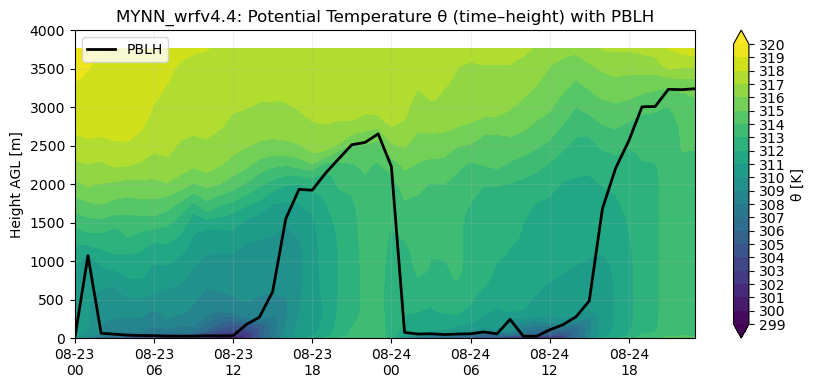

[OK] Saved figure → figs/MYNN_wrfv4.7.0_theta_z0-4000m.png


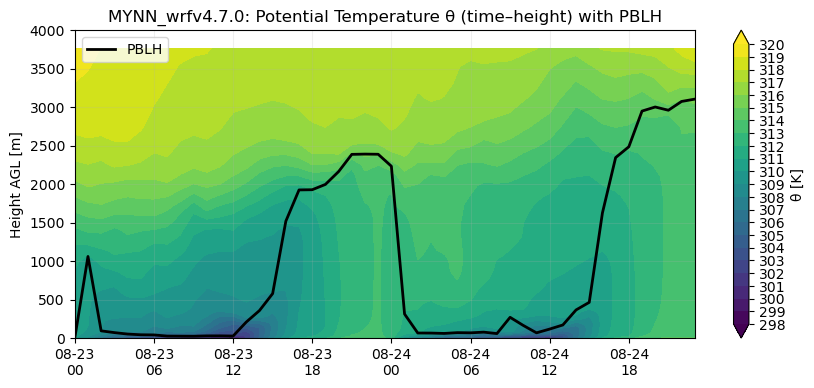

In [12]:
for name, ds in datasets.items():
    z = geopotential_height_agl(ds, j0, i0)
    pr = profiles[name]
    time_height_plot(
        ds, z, pr["theta"], pr["pblh"],
        title=f"{name}: Potential Temperature θ (time–height) with PBLH",
        cbar_label="θ [K]",
        varname="theta",
        zmax=4000,
        outdir="figs"
    )


## Time–height: wind speed & wind direction (Goal 3b)

[OK] Saved figure → figs/MYNN_wrfv4.4_wspd_z0-2000m.png


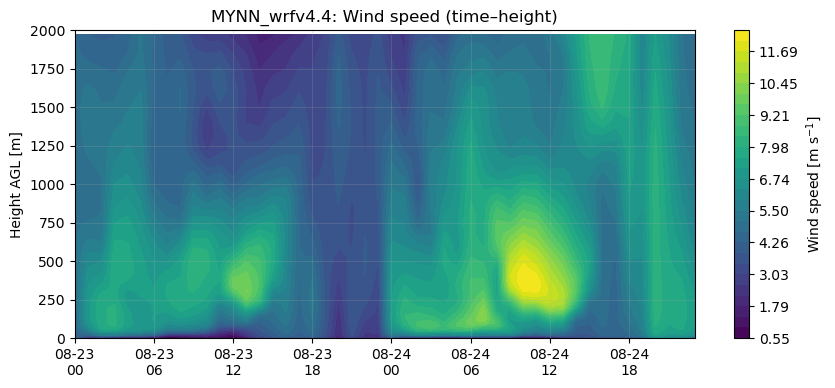

[OK] Saved figure → figs/MYNN_wrfv4.4_wdir_z0-2000m.png


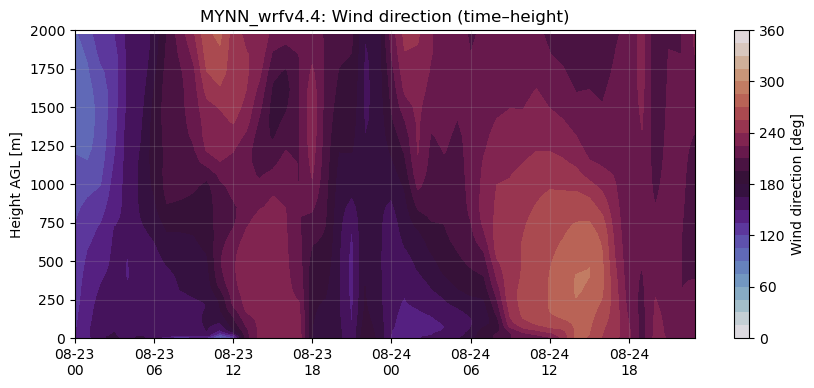

[OK] Saved figure → figs/MYNN_wrfv4.7.0_wspd_z0-2000m.png


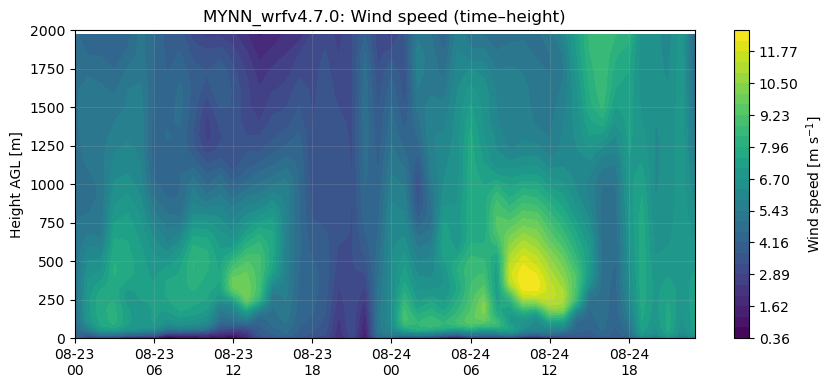

[OK] Saved figure → figs/MYNN_wrfv4.7.0_wdir_z0-2000m.png


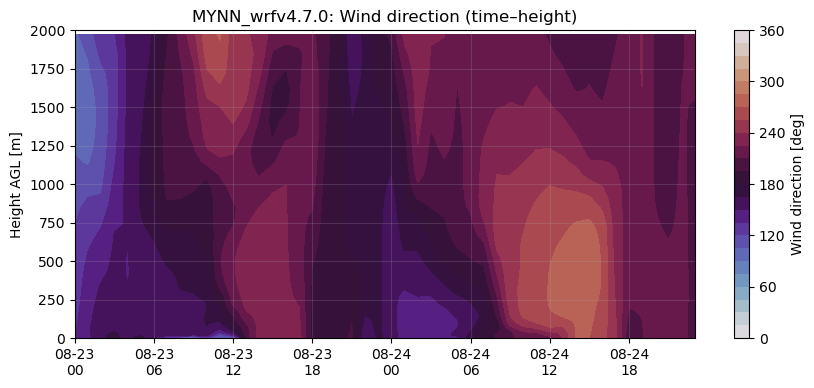

In [13]:
for name, ds in datasets.items():
    z = geopotential_height_agl(ds, j0, i0)
    pr = profiles[name]

    time_height_simple(
        ds, z, pr["wspd"],
        f"{name}: Wind speed (time–height)",
        "Wind speed [m s$^{-1}$]",
        levels=30,
        zmax=2000,
        cyclic=False,
        varname="wspd"
    )

    time_height_simple(
        ds, z, pr["wdir"],
        f"{name}: Wind direction (time–height)",
        "Wind direction [deg]",
        levels=np.arange(0, 361, 15),
        zmax=2000,
        cyclic=True,
        varname="wdir"
    )

    

## Time–height: TKE (Goal 3c)

<xarray.DataArray 'QKE' ()>
dask.array<_nanmin_skip-aggregate, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>
[OK] Saved figure → figs/MYNN_wrfv4.4_QKE_z0-2000m.png


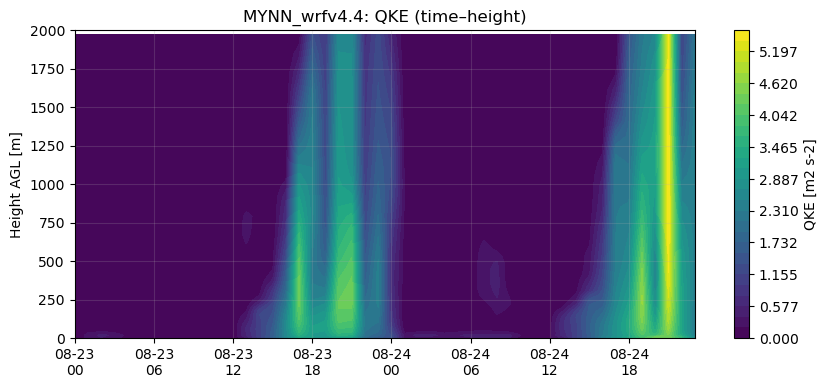

<xarray.DataArray 'QKE' ()>
dask.array<_nanmin_skip-aggregate, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>
[OK] Saved figure → figs/MYNN_wrfv4.7.0_QKE_z0-2000m.png


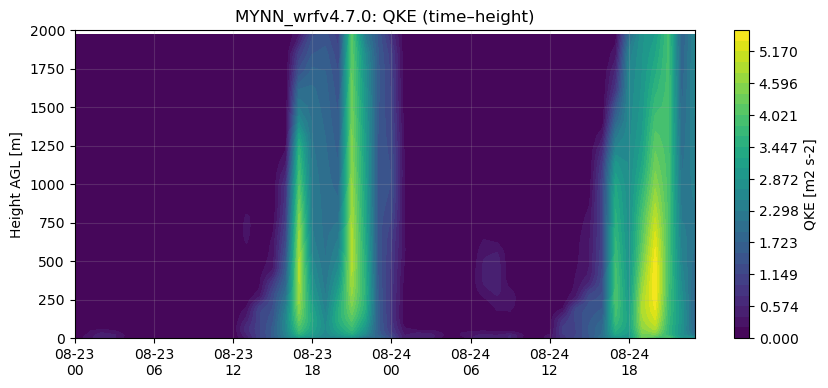

In [14]:
for name, ds in datasets.items():
    z = geopotential_height_agl(ds, j0, i0)
    pr = profiles[name]

    if pr["tke"] is None:
        print(f"{name}: No TKE variable found (looked for TKE_PBL, TKE, QKE).")
        continue

    tke_name = pr["tke_name"]
    units = pr["tke"].attrs.get("units", "")

    
    print(np.min(pr["tke"]))
    
    time_height_simple(
        ds, z, pr["tke"],
        title=f"{name}: {tke_name} (time–height)",
        cbar_label=f"{tke_name} [{units}]",
        levels=30,
        zmax=2000,
        cyclic=False,
        cmap="viridis",
        varname=tke_name,
        outdir="figs"
    )


## Time series of u* (Goal 3d)

In [15]:
def safe_slug(s):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(s))

def plot_point_timeseries_profiles(
    datasets,
    profiles,
    key,                      # e.g., "ust", "t2", "q2", "pblh", "tslb", "smois"
    title=None,
    ylabel=None,
    units=None,
    layer=None,               # for soil-like arrays (tslb/smois): choose layer index
    marker="o",
    outdir="figs",
    fname_prefix=None,
):
    """
    Plot a time series at the selected point for each case using profiles[name][key].

    Parameters
    ----------
    datasets : dict[str, xr.Dataset]
        Used only for time coordinate ds["time"].
    profiles : dict[str, dict[str, xr.DataArray]]
        profiles[name][key] must exist and be 1D over time (or 2D time x layer).
    key : str
        The profiles key to plot (e.g., "ust", "pblh", "t2", "q2", "tslb", "smois").
    layer : int or None
        If profiles[name][key] has an extra dimension (e.g., soil layer), pick layer index.
    """

    fig, ax = plt.subplots(figsize=(10, 4))
    any_plotted = False
    inferred_units = None

    for name, ds in datasets.items():
        if name not in profiles or key not in profiles[name] or profiles[name][key] is None:
            print(f"[WARN] {name}: profiles['{key}'] not found (or None). Skipping.")
            continue

        da = profiles[name][key]

        # Pick layer if needed (soil variables often have dims like soil_layers_stag/soil_layers)
        if layer is not None and da.ndim >= 2:
            # choose the first non-time dim as "layer"
            # common patterns: (Time, soil_layers_stag) or (time, soil_layers)
            layer_dim = [d for d in da.dims if d.lower() not in ("time",)]
            if len(layer_dim) == 0:
                print(f"[WARN] {name}: layer specified but no non-time dim found for '{key}'. Using as-is.")
            else:
                da = da.isel({layer_dim[0]: layer})

        # After layer selection, reduce any remaining non-time dims (shouldn't happen, but safe)
        other_dims = [d for d in da.dims if d.lower() != "time"]
        if len(other_dims) > 1:
            # still has more than one non-time dim
            sel = {d: 0 for d in other_dims[1:]}
            print(f"[WARN] {name}: '{key}' still has extra dims {other_dims}; taking first index {sel}.")
            da = da.isel(sel)

        # Get time axis from dataset (your ds already has ds["time"])
        t = ds["time"].values

        ax.plot(t, da.values, marker=marker, label=name)
        any_plotted = True

        if inferred_units is None and hasattr(da, "attrs"):
            inferred_units = da.attrs.get("units", None)

    if not any_plotted:
        print("[ERROR] Nothing was plotted (missing profiles key for all datasets?).")
        return

    # Title / labels
    if title is None:
        title = f"{key} at selected point"
        if layer is not None:
            title += f" (layer {layer})"

    if units is None:
        units = inferred_units or ""

    if ylabel is None:
        ylabel = f"{key} [{units}]" if units else key

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Time")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.autofmt_xdate()

    # ---- Save with a sane filename ----
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    prefix = safe_slug(fname_prefix if fname_prefix is not None else title.split(":")[0])
    layer_tag = f"_layer{layer}" if layer is not None else ""
    save = outdir / f"{prefix}_{safe_slug(key)}{layer_tag}_timeseries.png"

    fig.savefig(save, dpi=200, bbox_inches="tight")
    print(f"[OK] Saved figure → {save}")

    plt.show()


[OK] Saved figure → figs/Friction_velocity_u_at_selected_point_ust_timeseries.png


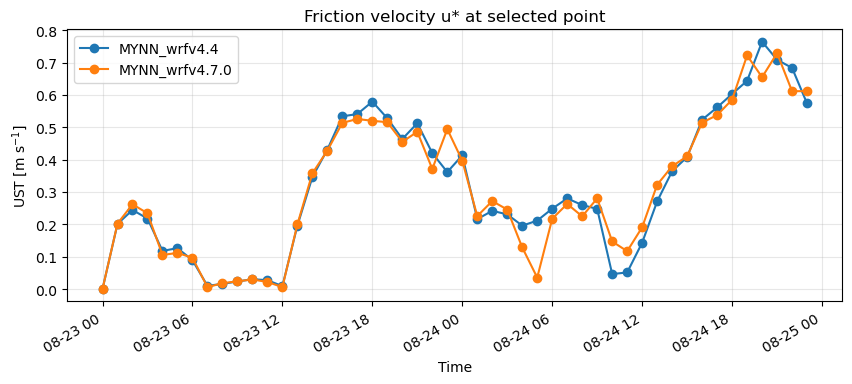

In [16]:
plot_point_timeseries_profiles(datasets, profiles, "ust",
                               title="Friction velocity u* at selected point",
                               ylabel="UST [m s$^{-1}$]")



[OK] Saved figure → figs/PBL_height_at_selected_point_pblh_timeseries.png


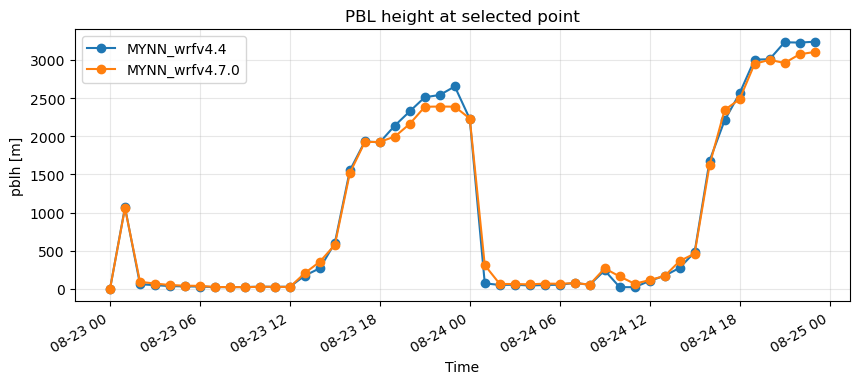

[OK] Saved figure → figs/Soil_temperature_at_selected_point_tslb_layer0_timeseries.png


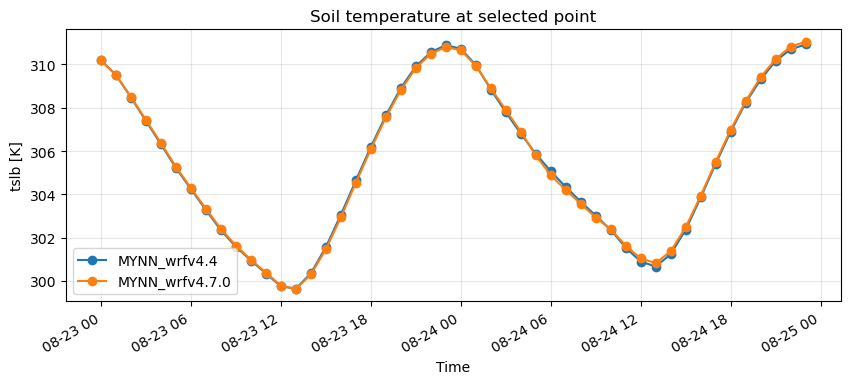

[OK] Saved figure → figs/Soil_moisture_at_selected_point_smois_layer1_timeseries.png


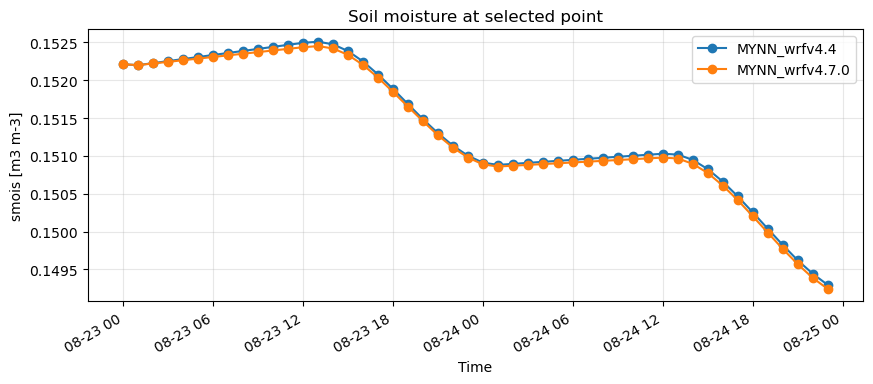

[OK] Saved figure → figs/2-m_Temperature_t2_layer1_timeseries.png


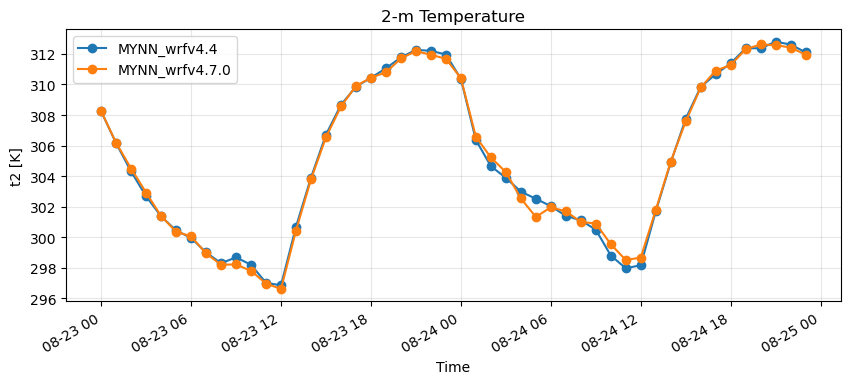

In [17]:
plot_point_timeseries_profiles(datasets, profiles, "pblh",
                               title="PBL height at selected point")

plot_point_timeseries_profiles(datasets, profiles, "tslb",
                               title="Soil temperature at selected point",
                               layer=0)

plot_point_timeseries_profiles(datasets, profiles, "smois",
                               title="Soil moisture at selected point",
                               layer=1)

plot_point_timeseries_profiles(datasets, profiles, "t2",
                               title="2-m Temperature",
                               layer=1)


## Compare multiple simulations

In [ ]:
def interp_to_height(z_agl, field, z_target):
    """
    Interpolate a (Time, bottom_top) field to a target height using 1D interp each time.
    Returns (Time,) array.
    """
    # For teaching: use numpy interp per time
    out = []
    for tt in range(field.shape[0]):
        z = z_agl.isel(Time=tt).values
        f = field.isel(Time=tt).values
        # Require monotonic z (should be)
        out.append(np.interp(z_target, z, f))
    return np.array(out)

z_targets = [40, 100, 200]
var_to_compare = "wspd"  # "theta", "wspd", etc.

fig, axes = plt.subplots(len(z_targets), 1, figsize=(10, 3*len(z_targets)), sharex=True)

for ax, zt in zip(axes, z_targets):
    for name, ds in datasets.items():
        z = geopotential_height_agl(ds, j0, i0)
        pr = profiles[name]
        series = interp_to_height(z, pr[var_to_compare], zt)
        ax.plot(ds["time"].values, series, marker="o", label=name)
    ax.set_title(f"{var_to_compare} at {zt} m AGL")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Time")
fig.autofmt_xdate()
plt.show()
